In [264]:
import pandas
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data_normal = pandas.read_table('../Graph and Features/AttackFreeGraph_GraphFeatures.txt')
data_dos = pandas.read_table('../Graph and Features/dosAttackGraph_GraphFeatures.txt')
data_fuzzy = pandas.read_table('../Graph and Features/fuzzyAttackGraph_GraphFeatures.txt')
data_spoofy_RPM_gauge = pandas.read_table('../Graph and Features/SpoofingAttackGraph_RPM_gauge_GraphFeatures.txt')
data_replay = pandas.read_table('../Graph and Features/ReplayAttackGraph_GraphFeatures.txt')

# 修改 State 列
data_dos.loc[data_dos['State'] == False, 'State'] = 'Dos'
data_fuzzy.loc[data_fuzzy['State'] == False, 'State'] = 'Fuzzy'
data_spoofy_RPM_gauge.loc[data_spoofy_RPM_gauge['State'] == False, 'State'] = 'Spoofy'
data_replay.loc[data_replay['State'] == False, 'State'] = 'Replay'

# 将五个数据集按行合并
combined_data = pandas.concat([data_normal, data_dos, data_fuzzy, data_spoofy_RPM_gauge, data_replay], ignore_index=True)

data = combined_data.drop("No.", axis=1)
dataset = data.values


l = 4944 + 18328 + 19194 + 23108 + 2381
# print(dataset)
# 分割特征和标签
X = dataset[:,0:9]  # 选择特征列
State = dataset[:, -1]  # State列
counter1 = 0
counter2 = 0

# print(len(dataset))
# break
y = []
x=[]
# 根据 State 判断类别
for i in range(len(dataset)):
#     print(State[i])
    if State[i] == True:
        y.append(0)  # 类别为 normal
        counter1 += 1
        
    else:
        # 进一步判断攻击类型
        attack_type = dataset[i, -1]
        if attack_type == 'Dos':
            y.append(1)
        elif attack_type == 'Fuzzy':
            y.append(2)
        elif attack_type == 'Spoofy':
            y.append(3)
        elif attack_type == 'Replay':
            y.append(4)
        counter2 += 1    
   
# print(len(y))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建决策树分类器
clf = DecisionTreeClassifier(random_state=42, max_depth = 7)

# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

# 计算每个攻击类型的准确率
accuracy_normal = accuracy_score([0 if label == 0 else -1 for label in y_test], [0 if pred == 0 else -1 for pred in y_pred])
accuracy_dos = accuracy_score([1 if label == 1 else -1 for label in y_test], [1 if pred == 1 else -1 for pred in y_pred])
accuracy_fuzzy = accuracy_score([2 if label == 2 else -1 for label in y_test], [2 if pred == 2 else -1 for pred in y_pred])
accuracy_spoofy = accuracy_score([3 if label == 3 else -1 for label in y_test], [3 if pred == 3 else -1 for pred in y_pred])
accuracy_replay = accuracy_score([4 if label == 4 else -1 for label in y_test], [4 if pred == 4 else -1 for pred in y_pred])
# target_names = [ "Normal", "Spoofing", "Fuzzing", "Flooding", "Replay"]

# print('classification report')

# print(classification_report(y_test, y_pred, target_names=target_names))

print(f"Normal 准确率: {accuracy_normal:.6f}")
print(f"Dos 准确率: {accuracy_dos:.6f}")
print(f"Fuzzy 准确率: {accuracy_fuzzy:.6f}")
print(f"Spoofy 准确率: {accuracy_spoofy:.6f}")
print(f"Replay 准确率: {accuracy_replay:.6f}")

# 计算整体评估指标  
overall_accuracy = accuracy_score(y_test, y_pred)
overall_precision = precision_score(y_test, y_pred, average='weighted')  
overall_recall = recall_score(y_test, y_pred, average='weighted')  
overall_f1 = f1_score(y_test, y_pred, average='weighted')  

print(f"整体准确率: {overall_accuracy:.6f}")
print(f"整体 Precision: {overall_precision:.6f}")  
print(f"整体 Recall: {overall_recall:.6f}")  
print(f"整体 F1: {overall_f1:.6f}")  

conf_matrix = confusion_matrix(y_test, y_pred)
# 打印混淆矩阵
print("混淆矩阵:")
print(conf_matrix)
# 计算评估指标
accuracy = [accuracy_normal, accuracy_dos, accuracy_fuzzy, accuracy_spoofy, accuracy_replay]
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
# print(accuracy)
# 将评估指标放入DataFrame中
df = pd.DataFrame({'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}, index=['Normal', 'Dos', 'Fuzzy', 'Spoofy', 'Replay'])
df.index.name = 'Attack Type'

# 打印表格
print(df)
print(counter1,counter2,counter1 +counter2)

Normal 准确率: 0.996589
Dos 准确率: 0.996540
Fuzzy 准确率: 0.999123
Spoofy 准确率: 0.996394
Replay 准确率: 0.999951
整体准确率: 0.994299
整体 Precision: 0.994294
整体 Recall: 0.994299
整体 F1: 0.994278
混淆矩阵:
[[13059     2     0     0     0]
 [   22  1614     0    34     0]
 [   17     1  1993     0     0]
 [   28    12     0  3170     0]
 [    1     0     0     0   569]]
             Accuracy  Precision    Recall        F1
Attack Type                                         
Normal       0.996589   0.994820  0.999847  0.997327
Dos          0.996540   0.990792  0.966467  0.978478
Fuzzy        0.999123   1.000000  0.991049  0.995504
Spoofy       0.996394   0.989388  0.987539  0.988463
Replay       0.999951   1.000000  0.998246  0.999122
43578 24827 68405


决策树深度 1 的整体准确率: 0.785693
决策树深度 2 的整体准确率: 0.882419
决策树深度 3 的整体准确率: 0.958484
决策树深度 4 的整体准确率: 0.986161
决策树深度 5 的整体准确率: 0.993763
决策树深度 6 的整体准确率: 0.993714
决策树深度 7 的整体准确率: 0.994299
决策树深度 8 的整体准确率: 0.994640
决策树深度 9 的整体准确率: 0.994835
决策树深度 10 的整体准确率: 0.994835
决策树深度 11 的整体准确率: 0.995078
决策树深度 12 的整体准确率: 0.994932
决策树深度 13 的整体准确率: 0.995030
决策树深度 14 的整体准确率: 0.994689
决策树深度 15 的整体准确率: 0.994591
决策树深度 16 的整体准确率: 0.994153
决策树深度 17 的整体准确率: 0.994201
决策树深度 18 的整体准确率: 0.993519
决策树深度 19 的整体准确率: 0.993714
决策树深度 20 的整体准确率: 0.993470


D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabt

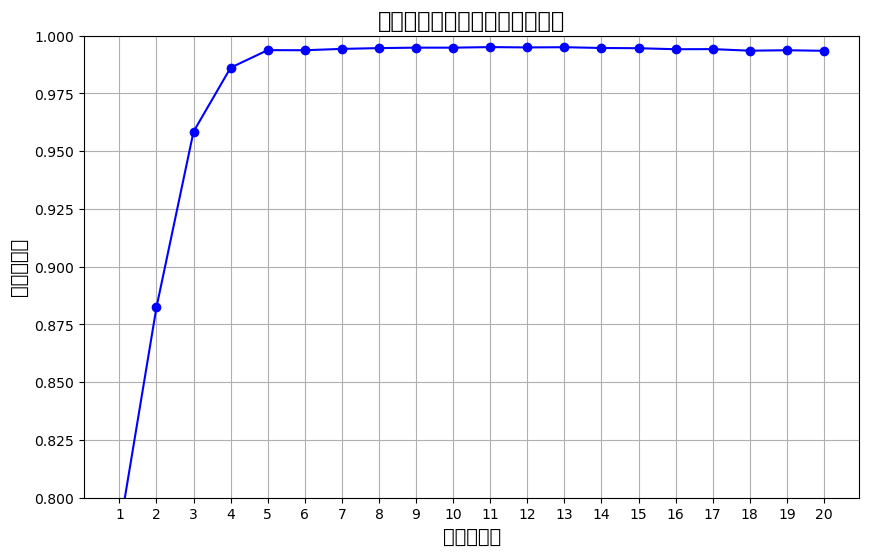

In [67]:
import pandas  
import pandas as pd  
from sklearn.metrics import confusion_matrix  
from sklearn.tree import DecisionTreeClassifier  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  
from sklearn.model_selection import train_test_split  
import matplotlib.pyplot as plt  

# 读取数据  
data_normal = pandas.read_table('../Graph and Features/AttackFreeGraph_GraphFeatures.txt')  
data_dos = pandas.read_table('../Graph and Features/dosAttackGraph_GraphFeatures.txt')  
data_fuzzy = pandas.read_table('../Graph and Features/fuzzyAttackGraph_GraphFeatures.txt')  
data_spoofy_RPM_gauge = pandas.read_table('../Graph and Features/SpoofingAttackGraph_RPM_gauge_GraphFeatures.txt')  
data_replay = pandas.read_table('../Graph and Features/ReplayAttackGraph_GraphFeatures.txt')  

# 修改 State 列  
data_dos.loc[data_dos['State'] == False, 'State'] = 'Dos'  
data_fuzzy.loc[data_fuzzy['State'] == False, 'State'] = 'Fuzzy'  
data_spoofy_RPM_gauge.loc[data_spoofy_RPM_gauge['State'] == False, 'State'] = 'Spoofy'  
data_replay.loc[data_replay['State'] == False, 'State'] = 'Replay'  

# 将五个数据集按行合并  
combined_data = pandas.concat([data_normal, data_dos, data_fuzzy, data_spoofy_RPM_gauge, data_replay], ignore_index=True)  

data = combined_data.drop("No.", axis=1)  
dataset = data.values  

# 分割特征和标签  
X = dataset[:, 0:9]  # 选择特征列  
State = dataset[:, -1]  # State列  

y = []  
# 根据 State 判断类别  
for i in range(len(dataset)):  
    if State[i] == True:  
        y.append(0)  # 类别为 normal  
    else:  
        # 进一步判断攻击类型  
        attack_type = dataset[i, -1]  
        if attack_type == 'Dos':  
            y.append(1)  
        elif attack_type == 'Fuzzy':  
            y.append(2)  
        elif attack_type == 'Spoofy':  
            y.append(3)  
        elif attack_type == 'Replay':  
            y.append(4)  

# 划分训练集和测试集  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  

# 存储不同深度的整体准确率  
depths = range(1, 21)  # 决策树深度从 1 到 10  
accuracies = []  

# 遍历不同的深度  
for depth in depths:  
    # 创建决策树分类器  
    clf = DecisionTreeClassifier(random_state=42, max_depth=depth)  
    # 训练模型  
    clf.fit(X_train, y_train)  
    # 预测  
    y_pred = clf.predict(X_test)  
    # 计算整体准确率  
    overall_accuracy = accuracy_score(y_test, y_pred)  
    accuracies.append(overall_accuracy)  
    print(f"决策树深度 {depth} 的整体准确率: {overall_accuracy:.6f}")  

# 绘制深度与准确率的曲线图  
plt.figure(figsize=(10, 6))  
plt.plot(depths, accuracies, marker='o', linestyle='-', color='b')  
plt.title('决策树深度与整体准确率的关系', fontsize=16)  
plt.xlabel('决策树深度', fontsize=14)  
plt.ylabel('整体准确率', fontsize=14)  
plt.xticks(depths)  
plt.ylim(0.8, 1.0)  # 限制 y 轴范围为 0.0 到 1.0  
plt.grid(True)  
plt.show()

In [177]:
import time  
clf = DecisionTreeClassifier(random_state=42, max_depth=7)  
# 对训练部分计时  
start_train = time.time()  
clf.fit(X_train, y_train)  
end_train = time.time()  
train_time = (end_train - start_train) * 1000  # 转换为毫秒  
print(f"训练时间: {train_time:.2f} 毫秒")  

# 对测试部分计时  
start_test = time.time()  
y_pred = clf.predict(X_test)  
end_test = time.time()  
test_time = (end_test - start_test) * 1000  # 转换为毫秒  
print(f"测试时间: {test_time:.2f} 毫秒")

训练时间: 136.86 毫秒
测试时间: 7.01 毫秒


In [9]:
from sklearn.ensemble import RandomForestClassifier
import time  

# 初始化随机森林模型
clf = RandomForestClassifier(random_state=42)

# 对训练部分计时  
start_train = time.time()  
clf.fit(X_train, y_train)  
end_train = time.time()  
train_time = (end_train - start_train) * 1000  # 转换为毫秒  
print(f"训练时间: {train_time:.2f} 毫秒")  

# 对测试部分计时  
start_test = time.time()  
y_pred = clf.predict(X_test)  
end_test = time.time()  
test_time = (end_test - start_test) * 1000  # 转换为毫秒  
print(f"测试时间: {test_time:.2f} 毫秒")


训练时间: 7344.38 毫秒
测试时间: 208.36 毫秒


In [147]:
from sklearn.naive_bayes import GaussianNB
import time

# 初始化GGNB（使用高斯朴素贝叶斯作为示例）
clf = GaussianNB()

# 对训练部分计时  
start_train = time.time()  
clf.fit(X_train, y_train)  
end_train = time.time()  
train_time = (end_train - start_train) * 1000  # 转换为毫秒  
print(f"训练时间: {train_time:.2f} 毫秒")  

# 对测试部分计时  
start_test = time.time()  
y_pred = clf.predict(X_test)  
end_test = time.time()  
test_time = (end_test - start_test) * 1000  # 转换为毫秒  
print(f"测试时间: {test_time:.2f} 毫秒")


训练时间: 64.55 毫秒
测试时间: 28.57 毫秒


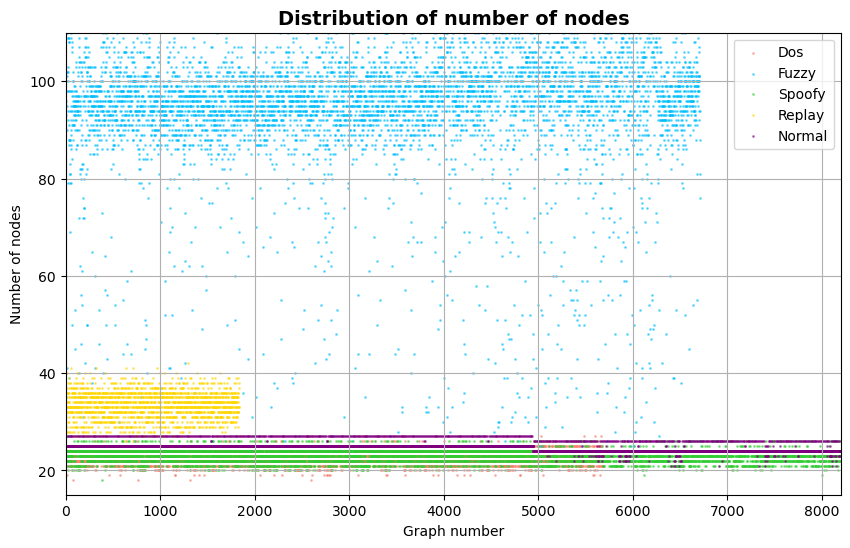

In [2]:
#Nodes
import matplotlib.pyplot as plt
import numpy as np
import pandas
import pandas as pd
data_normal = pandas.read_table('../Graph and Features/AttackFreeGraph_GraphFeatures.txt')
data_dos = pandas.read_table('../Graph and Features/dosAttackGraph_GraphFeatures.txt')
data_fuzzy = pandas.read_table('../Graph and Features/fuzzyAttackGraph_GraphFeatures.txt')
data_spoofy_RPM_gauge = pandas.read_table('../Graph and Features/SpoofingAttackGraph_RPM_gauge_GraphFeatures.txt')
data_replay = pandas.read_table('../Graph and Features/ReplayAttackGraph_GraphFeatures.txt')

# 修改 State 列
data_dos.loc[data_dos['State'] == False, 'State'] = 'Dos'
data_fuzzy.loc[data_fuzzy['State'] == False, 'State'] = 'Fuzzy'
data_spoofy_RPM_gauge.loc[data_spoofy_RPM_gauge['State'] == False, 'State'] = 'Spoofy'
data_replay.loc[data_replay['State'] == False, 'State'] = 'Replay'

# 将五个数据集按行合并
combined_data = pandas.concat([data_normal, data_dos, data_fuzzy, data_spoofy_RPM_gauge, data_replay], ignore_index=True)

data = combined_data.drop("No.", axis=1)
dataset = data.values

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]
feature_values = X[:, 4]

# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 0].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 0].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 0].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 0].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 0].astype(float)  # 未受攻击的样本值
# len_data = len(dos_values)
# print(len_data)
# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Number of nodes')
plt.title('Distribution of number of nodes',weight='bold', size=14)
plt.legend(loc='upper right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(15, 110)
plt.savefig('../PNG/Distribution of Features/number of nodes.png', dpi=600, bbox_inches='tight')
plt.show()


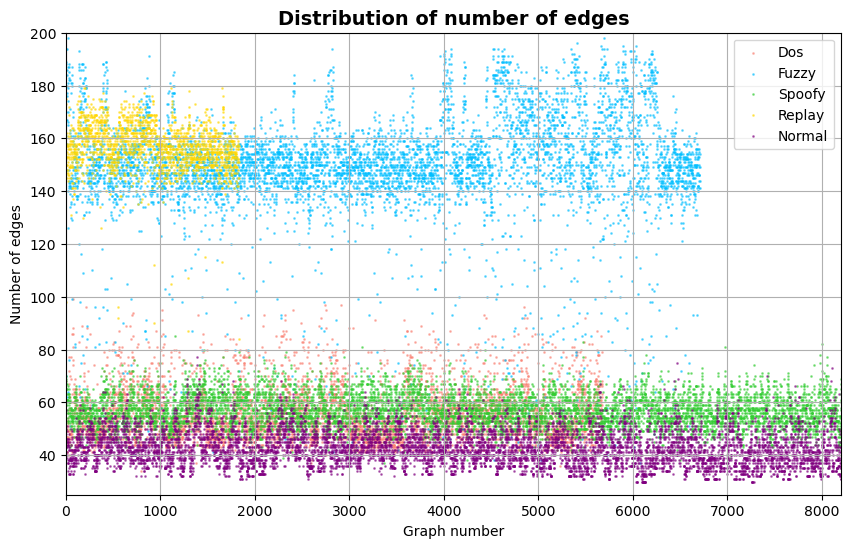

In [3]:
#edges
import matplotlib.pyplot as plt
import numpy as np

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]
# feature_values = X[:, 4]

# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 1].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 1].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 1].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 1].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 1].astype(float)  # 未受攻击的样本值
# len_data = len(dos_values)
# print(len_data)
# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Number of edges')
plt.title('Distribution of number of edges',weight='bold', size=14)
plt.legend()
plt.legend(loc='upper right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(25, 200)
plt.savefig('../PNG/Distribution of Features/number of edges.png', dpi=600, bbox_inches='tight')
plt.show()

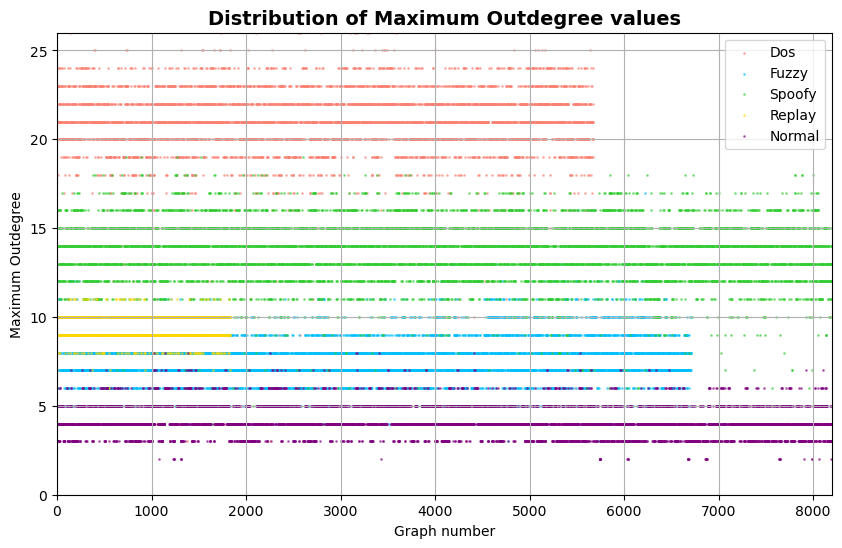

In [4]:
#Maximum Outdegree
import matplotlib.pyplot as plt
import numpy as np

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]


# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 4].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 4].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 4].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 4].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 4].astype(float)  # 未受攻击的样本值

# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Maximum Outdegree')
plt.title('Distribution of Maximum Outdegree values',weight='bold', size=14)
plt.legend(loc='upper right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(0, 26)
plt.savefig('../PNG/Distribution of Features/Maximum Outdegree values.png', dpi=600, bbox_inches='tight')
plt.show()


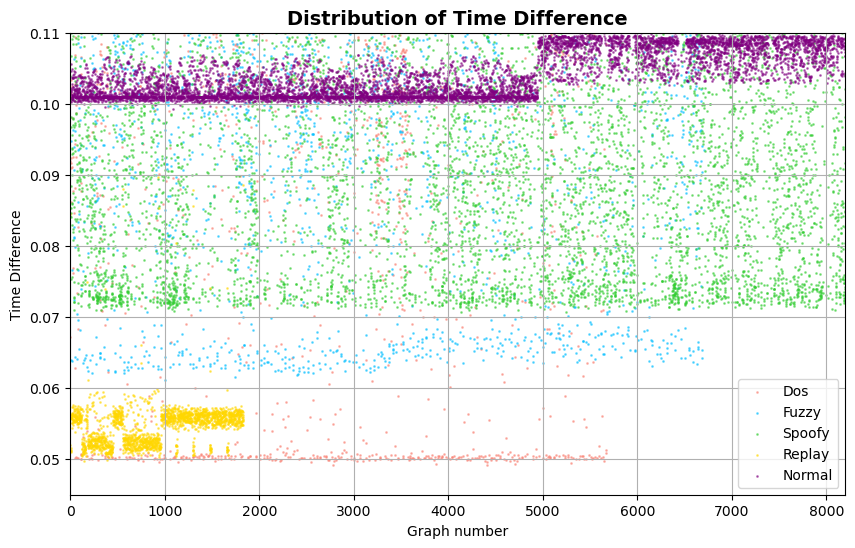

In [5]:
#Time Difference
import matplotlib.pyplot as plt
import numpy as np

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]

# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 6].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 6].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 6].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 6].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 6].astype(float)  # 未受攻击的样本值


# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Time Difference')
plt.title('Distribution of Time Difference',weight='bold', size=14)
plt.legend(loc='lower right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(0.045, 0.11)
plt.savefig('../PNG/Distribution of Features/Time Difference', dpi=600, bbox_inches='tight')
plt.show()

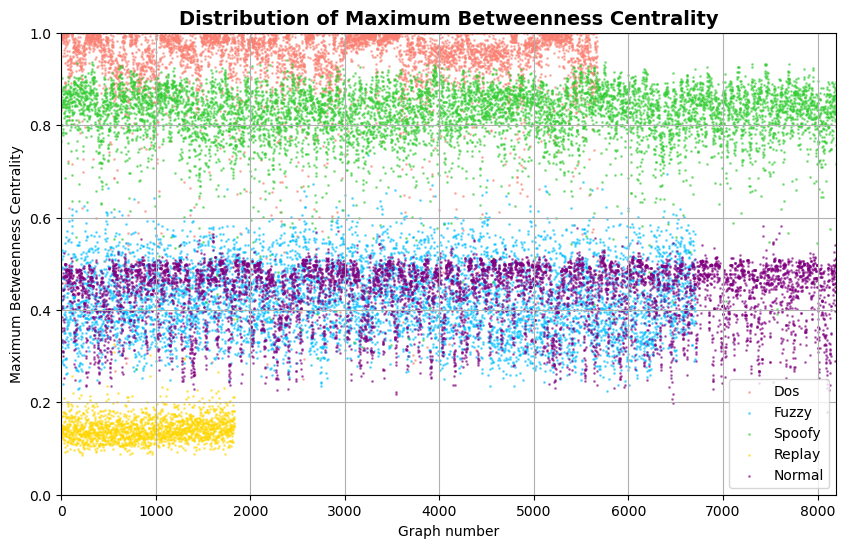

In [6]:
#betweenness_centrality
import matplotlib.pyplot as plt
import numpy as np

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]

# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 7].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 7].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 7].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 7].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 7].astype(float)  # 未受攻击的样本值

# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Maximum Betweenness Centrality')
plt.title('Distribution of Maximum Betweenness Centrality',weight='bold', size=14)
plt.legend(loc='lower right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(0, 1)
plt.savefig('../PNG/Distribution of Features/Maximum Betweenness Centrality', dpi=600, bbox_inches='tight')
plt.show()

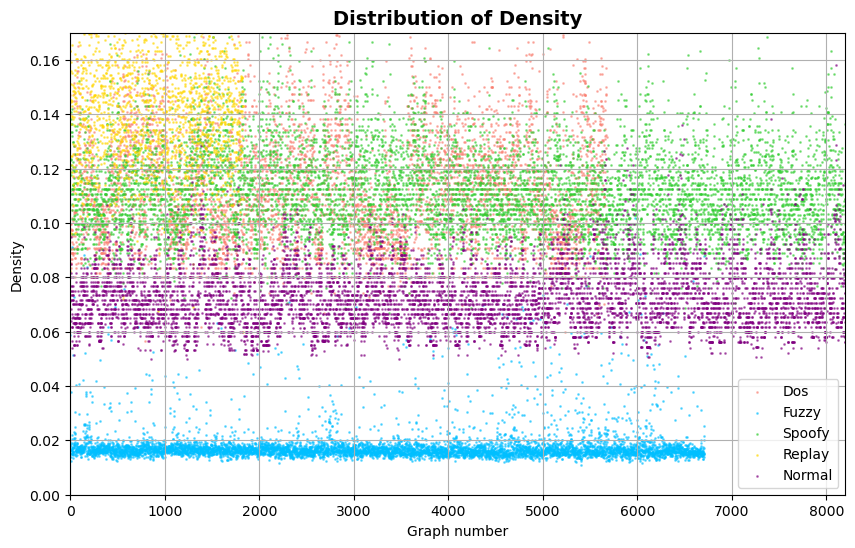

In [7]:
#betweenness_centrality
import matplotlib.pyplot as plt
import numpy as np

# 假设 X 包含了数据集

# 提取第一列特征的值
X = dataset[:, 0:]

# 根据攻击类型和未受攻击划分数据
dos_values = X[X[:, -1] == 'Dos'][:, 8].astype(float)  # Dos攻击样本值
fuzzy_values = X[X[:, -1] == 'Fuzzy'][:, 8].astype(float)  # Fuzzy攻击样本值
spoofy_values = X[X[:, -1] == 'Spoofy'][:, 8].astype(float)  # Spoofy攻击样本值
replay_values = X[X[:, -1] == 'Replay'][:, 8].astype(float)  # Replay攻击样本值
no_attack_values = X[X[:, -1] == True][:, 8].astype(float)  # 未受攻击的样本值


# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(dos_values)), dos_values, c='salmon', label='Dos', alpha=0.5, s=1)  # 修改为 'salmon' 颜色
plt.scatter(range(len(fuzzy_values)), fuzzy_values, c='deepskyblue', label='Fuzzy', alpha=0.5, s=1)  # 修改为 'skyblue' 颜色
plt.scatter(range(len(spoofy_values)), spoofy_values, c='limegreen', label='Spoofy', alpha=0.5, s=1)  # 修改为 'limegreen' 颜色
plt.scatter(range(len(replay_values)), replay_values, c='gold', label='Replay', alpha=0.5, s=1)  # 修改为 'gold' 颜色
plt.scatter(range(len(no_attack_values)), no_attack_values, c='purple', label='Normal', alpha=0.5, s=1)
# plt.legend(scatterpoints=10, markerscale=10, prop={'size': 120})
plt.xlabel('Graph number')
plt.ylabel('Density')
plt.title('Distribution of Density',weight='bold', size=14)
plt.legend(loc='lower right')  # 将图例放置在右上角
plt.grid(True)
plt.xlim(0, 8200)
plt.ylim(0, 0.17)
plt.savefig('../PNG/Distribution of Features/Density', dpi=600, bbox_inches='tight')
plt.show()

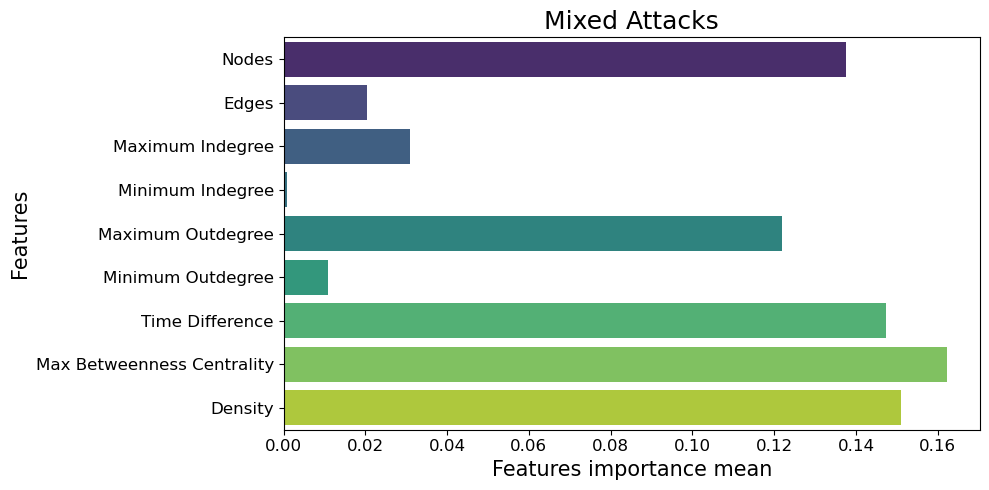

In [54]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def plot_feature_importance(X, y):
    features = X[:, 0:9]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    imps = permutation_importance(clf, X_test, y_test)
    feature_names = ["Nodes", "Edges", "Maximum Indegree", "Minimum Indegree", "Maximum Outdegree",
                     "Minimum Outdegree", "Time Difference", "Max Betweenness Centrality", "Density"]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=imps.importances_mean, y=feature_names, palette='viridis')
    plt.xlabel('Features importance mean', fontsize=15)
    plt.ylabel('Features', fontsize=15)
    plt.title('Mixed Attacks', fontsize=18)
    plt.tick_params(labelsize=12)
    plt.tight_layout()
    plt.savefig('../PNG/mixed/Feature Importance Analysis_Car_Hacking_.png', dpi=600, bbox_inches='tight')
    plt.show()

# 假设X和labels已被定义
plot_feature_importance(X, y)

混淆矩阵:
[[13059     2     0     0     0]
 [   22  1614     0    34     0]
 [   17     1  1993     0     0]
 [   28    12     0  3170     0]
 [    1     0     0     0   569]]


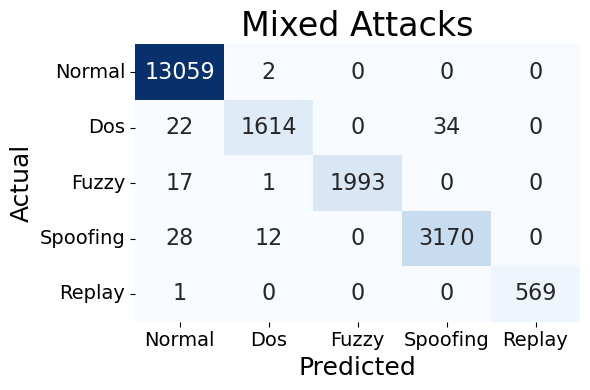

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 打印混淆矩阵
print("混淆矩阵:")
print(conf_matrix)

# 使用Seaborn绘制热力图展示混淆矩阵
plt.figure(figsize=(6, 4))
tick_labels = ['Normal', 'Dos', 'Fuzzy', 'Spoofing', 'Replay']
hm = sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', annot_kws={"size": 16},
                 xticklabels=tick_labels, yticklabels=tick_labels, cbar=False)
plt.xlabel('Predicted', fontsize=18)
plt.ylabel('Actual', fontsize=18)
plt.title('Mixed Attacks',fontsize=24)

hm.set_xticklabels(hm.get_xticklabels(), fontsize=14)
hm.set_yticklabels(hm.get_yticklabels(), fontsize=14, rotation=0)

plt.tight_layout()
plt.savefig('../PNG/mixed/confusion_matrix_Car_Hacking.png', dpi=600)
plt.show()


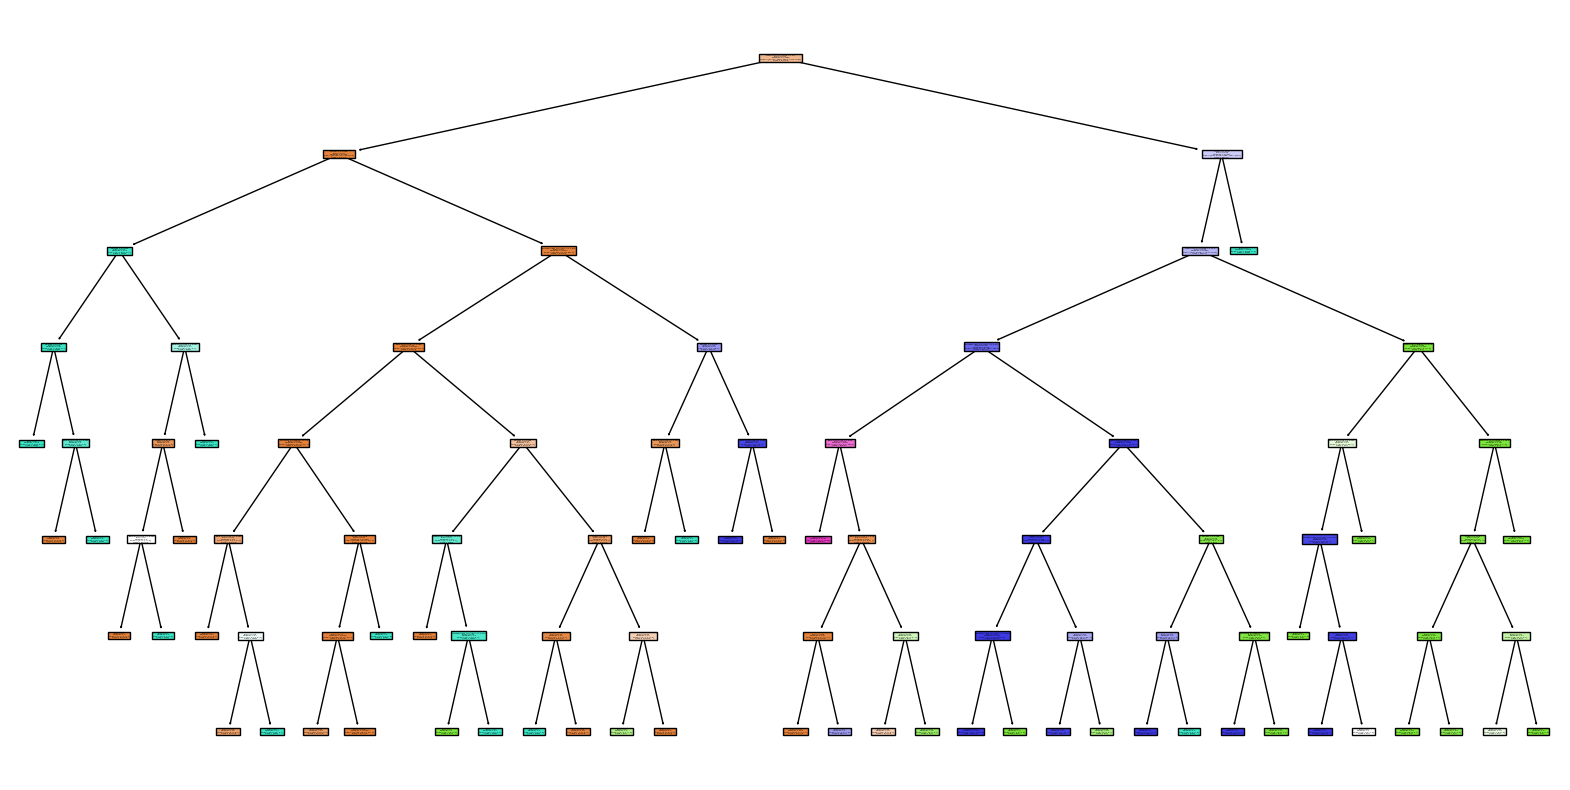

决策树的深度为: 7
决策树的内部节点数量为: 46


In [70]:
from sklearn.tree import plot_tree  
import matplotlib.pyplot as plt  

# 设置特征名称  
feature_names = ["Nodes", "Edges", "Maximum Indegree", "Minimum Indegree",   
                 "Maximum Outdegree", "Minimum Outdegree", "Time Difference",   
                 "betweenness_centrality", "density"]  

# 可视化决策树  
plt.figure(figsize=(20, 10))  
plot_tree(clf, feature_names=feature_names, class_names=['Normal', 'Dos', 'Fuzzy', 'Spoofy', 'Replay'], filled=True)  
plt.show()  

# 获取决策树的深度  
tree_depth = clf.tree_.max_depth  
print(f"决策树的深度为: {tree_depth}")  

# 获取内部节点数量  
node_count = clf.tree_.node_count  
children_left = clf.tree_.children_left  
children_right = clf.tree_.children_right  

# 内部节点是指既有左子节点又有右子节点的节点  
internal_nodes = sum((children_left != -1) & (children_right != -1))  
print(f"决策树的内部节点数量为: {internal_nodes}")  